# 🔬 LightGBM Overfit Lab — Generic Binary Classifier
## Works for any dataset: Fraud, Credit Risk, Churn, Default, etc.

> Built with LGBMClassifier — full sklearn compatibility. Auto-diagnosis included.

**How to use:** Edit Section 0 only, then Run All.

| Section | Topic |
|---------|-------|
| 0  | ⚙️ Configuration |
| 1  | 📥 Load & Validate |
| 2  | 🔍 EDA |
| 3  | 🔴 Baseline — detect overfit |
| 4  | 📊 Quick Gain Importance — leakage check on baseline |
| 5  | 🛠️ Fix #1 — Regularization |
| 6  | 🛠️ Fix #2 — Subsampling + Early Stopping → builds clf_es |
| 7  | 📊 Full Feature Importance — Permutation + SHAP on clf_es |
|    |    → Evidence-based feature removal |
| 8  | 🛠️ Fix #3 — Class Imbalance (on clean features) |
| 9  | 🔁 Cross Validation + Auto-Diagnosis (on clean features) |
| 10 | 🤖 Optuna — all fixes combined, auto-scaled (on clean features) |
| 11 | 🏆 Final Model — evaluation + best config |

## ⚙️ Install
Run once, then restart kernel.

In [1]:
!pip install lightgbm scikit-learn pandas numpy matplotlib seaborn imbalanced-learn optuna shap -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
import shap
import joblib
import json as _json
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              confusion_matrix, precision_recall_curve,
                              precision_score, recall_score, f1_score,
                              classification_report, roc_curve)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

plt.style.use("seaborn-v0_8-darkgrid")
COLORS = {
    "train"  : "#2196F3",
    "val"    : "#F44336",
    "test"   : "#9C27B0",
    "good"   : "#4CAF50",
    "warn"   : "#FF9800",
    "neutral": "#607D8B",
    "shap"   : "#E91E63",
}
print("All imports successful")


c:\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful


---
## Section 0 — ⚙️ Configuration
### 👉 THIS IS THE ONLY SECTION YOU NEED TO EDIT

> **Why AUPRC?** For imbalanced datasets (fraud, credit risk, churn),
> ROC-AUC and confusion matrix accuracy are misleading — a model that always
> predicts the majority class still scores ~0.5+ ROC-AUC.
> **AUPRC** is the correct metric: it focuses only on the positive class
> and a random classifier scores equal to the fraud rate (e.g. 0.002 for
> creditcard.csv), making performance much harder to inflate artificially.


In [3]:
DATASET_PATH   = "creditcard.csv"  # CSV, Excel or Parquet
TARGET_COL     = "Class"           # binary target column
DROP_COLS      = []                # IDs, dates, leaky cols
NEGATIVE_LABEL = "Not Fraud"       # class 0 label
POSITIVE_LABEL = "Fraud"           # class 1 label

TRAIN_SIZE     = 0.70
VAL_SIZE       = 0.15
TEST_SIZE      = 0.15

GAP_SEVERE     = 0.05
GAP_MODERATE   = 0.02

OPTUNA_TRIALS  = 50
RANDOM_STATE   = 42

# ── Metrics ──────────────────────────────────────────────────────────────
# OVERFITTING_METRIC: used for gap detection, early stopping, Optuna search.
# ROC-AUC is stable and low-variance — reliable for detecting overfit
# regardless of class imbalance. Keep this as "roc_auc".
OVERFITTING_METRIC = "roc_auc"

# EVALUATION_METRIC: used for reporting final model quality.
# AUPRC is the honest metric for imbalanced fraud/risk datasets.
# A random classifier scores equal to the fraud rate (~0.002 for creditcard).
# Change to "roc_auc" only if your dataset is balanced (>30% positive rate).
EVALUATION_METRIC  = "auprc"

print("Configuration set")
print(f"  Dataset             : {DATASET_PATH}")
print(f"  Target              : {TARGET_COL}")
print(f"  Classes             : 0={NEGATIVE_LABEL}  1={POSITIVE_LABEL}")
print(f"  Overfitting metric  : {OVERFITTING_METRIC} (gap detection + early stopping)")
print(f"  Evaluation metric   : {EVALUATION_METRIC} (reporting + model selection)")


Configuration set
  Dataset             : creditcard.csv
  Target              : Class
  Classes             : 0=Not Fraud  1=Fraud
  Overfitting metric  : roc_auc (gap detection + early stopping)
  Evaluation metric   : auprc (reporting + model selection)


---
## Section 1 — 📥 Load & Validate Dataset


In [4]:
def load_dataset(path):
    ext = path.split('.')[-1].lower()
    if ext == 'csv':     return pd.read_csv(path)
    elif ext in ['xlsx','xls']: return pd.read_excel(path)
    elif ext == 'parquet': return pd.read_parquet(path)
    else: raise ValueError(f'Unsupported file type: {ext}')

df = load_dataset(DATASET_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 284,807 rows x 31 columns


In [5]:
# Validate target
assert TARGET_COL in df.columns, f'Target column not found. Available: {list(df.columns)}'
assert df[TARGET_COL].nunique() == 2, f'Target must be binary. Found: {df[TARGET_COL].unique()}'

if set(df[TARGET_COL].unique()) != {0, 1}:
    le = LabelEncoder()
    df[TARGET_COL] = le.fit_transform(df[TARGET_COL])
    print(f'Target encoded: {le.classes_} -> [0, 1]')

pos_rate = df[TARGET_COL].mean()
neg_rate = 1 - pos_rate
ratio    = neg_rate / pos_rate
SCALE_POS_WEIGHT = round(ratio, 1)

print(f'{NEGATIVE_LABEL} (0): {df[TARGET_COL].value_counts()[0]:,}  ({neg_rate:.1%})')
print(f'{POSITIVE_LABEL} (1): {df[TARGET_COL].value_counts()[1]:,}  ({pos_rate:.1%})')
print(f'Imbalance ratio      : {ratio:.1f}:1')
print(f'scale_pos_weight     : {SCALE_POS_WEIGHT}  (auto-calculated)')

Not Fraud (0): 284,315  (99.8%)
Fraud (1): 492  (0.2%)
Imbalance ratio      : 577.9:1
scale_pos_weight     : 577.9  (auto-calculated)


In [6]:
# Drop cols, encode categoricals, handle nulls
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns if c != TARGET_COL]
if cat_cols:
    print(f'Encoding categoricals: {cat_cols}')
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

high_null = df.isnull().mean()
high_null = high_null[high_null > 0.5]
if len(high_null) > 0:
    print(f'Dropping >50% null columns: {list(high_null.index)}')
    df = df.drop(columns=high_null.index)
df = df.fillna(df.median(numeric_only=True))

# Split
FEATURES = [c for c in df.columns if c != TARGET_COL]
X, y = df[FEATURES], df[TARGET_COL]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(VAL_SIZE + TEST_SIZE), stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=TEST_SIZE/(VAL_SIZE+TEST_SIZE),
    stratify=y_temp, random_state=RANDOM_STATE)

print(f'Train : {len(X_train):,} rows  |  {POSITIVE_LABEL} rate: {y_train.mean():.1%}')
print(f'Val   : {len(X_val):,} rows  |  {POSITIVE_LABEL} rate: {y_val.mean():.1%}')
print(f'Test  : {len(X_test):,} rows  |  {POSITIVE_LABEL} rate: {y_test.mean():.1%}')
print(f'Features: {len(FEATURES)}')

# ── Auto-scaling — driven entirely by dataset dimensions ────────────────────
n_features = len(FEATURES)
n_train    = len(X_train)
n_val      = len(X_val)
print(f"Feature count : {n_features}")
print(f"Train rows    : {n_train:,}")
print(f"Val rows      : {n_val:,}")

# Permutation repeats: more repeats = more reliable, but scales with feature count
# Formula: start at 20, reduce by 1 for every 10 features above 20, floor at 5
_perm_reps = max(5, 20 - (n_features - 20) // 10) if n_features > 20 else 20

# SHAP: always use full val set — no sampling limit
_shap_rows = n_val

# Chart display: show enough bars to be informative without being unreadable
# Rule: show top 20% of features, minimum 10, maximum 50
_chart_top_n = max(10, min(50, int(n_features * 0.20)))

# Top-N candidates: evenly spaced percentiles of feature count + full set
# Generates ~10 candidates regardless of feature count
_pcts = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 0.90, 1.0]
_top_n_candidates = sorted(set(
    max(5, int(n_features * p)) for p in _pcts
))
_top_n_candidates = [n for n in _top_n_candidates if n <= n_features]

# num_leaves sweep: scale with feature count
# More features = model can use more leaves effectively
_nl_sweep = sorted(set([
    max(15, int(2 ** (3 + n_features / 50))),   # small
    max(31, int(2 ** (4 + n_features / 50))),   # medium
    max(63, int(2 ** (5 + n_features / 50))),   # large
    max(127, int(2 ** (6 + n_features / 50))),  # very large
    max(255, int(2 ** (7 + n_features / 50))),  # max
]))
_nl_sweep = [nl for nl in _nl_sweep if nl <= 2**10]  # hard cap at 1024 leaves

print(f"Permutation repeats  : {_perm_reps}")
print(f"SHAP rows            : {_shap_rows:,}")
print(f"Chart top-N          : {_chart_top_n}")
print(f"Top-N candidates     : {_top_n_candidates}")
print(f"num_leaves sweep     : {_nl_sweep}")


Train : 199,364 rows  |  Fraud rate: 0.2%
Val   : 42,721 rows  |  Fraud rate: 0.2%
Test  : 42,722 rows  |  Fraud rate: 0.2%
Features: 30
Feature count : 30
Train rows    : 199,364
Val rows      : 42,721
Permutation repeats  : 19
SHAP rows            : 42,721
Chart top-N          : 10
Top-N candidates     : [5, 6, 9, 12, 15, 18, 22, 27, 30]
num_leaves sweep     : [15, 31, 63, 127, 255]


### Helper Functions — run before any experiment

In [7]:
all_experiment_results = {}

def get_proba(clf, X):
    """Get positive class probabilities."""
    return clf.predict_proba(X)[:, 1]

def score(y_true, proba):
    """Return both ROC-AUC and AUPRC."""
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "auprc"  : average_precision_score(y_true, proba),
    }

def evaluate(clf, tag="", store=True):
    """Evaluate on all 3 splits.
    Gap is measured on OVERFITTING_METRIC (stable).
    Both metrics reported for full picture.
    """
    feat     = clf.feature_name_
    Xtr, Xva, Xte = X_train[feat], X_val[feat], X_test[feat]
    tr_s = score(y_train, get_proba(clf, Xtr))
    va_s = score(y_val,   get_proba(clf, Xva))
    te_s = score(y_test,  get_proba(clf, Xte))
    gap  = tr_s[OVERFITTING_METRIC] - va_s[OVERFITTING_METRIC]
    flag = "🔴 SEVERE" if gap > GAP_SEVERE else ("🟡 MODERATE" if gap > GAP_MODERATE else "🟢 HEALTHY")
    _roc = va_s["roc_auc"]
    _apr = va_s["auprc"]
    print(f"  {tag:<30} ROC-AUC={_roc:.4f}  AUPRC={_apr:.4f}  Gap(roc)={gap:.4f}  {flag}")
    result = {
        "train"        : tr_s[OVERFITTING_METRIC],
        "val"          : va_s[EVALUATION_METRIC],
        "test"         : te_s[EVALUATION_METRIC],
        "val_roc_auc"  : va_s["roc_auc"],
        "val_auprc"    : va_s["auprc"],
        "test_roc_auc" : te_s["roc_auc"],
        "test_auprc"   : te_s["auprc"],
        "gap"          : gap,
    }
    if store and tag:
        all_experiment_results[tag] = result
    return result

def plot_curves(clf, title):
    """Plot train/val curves using OVERFITTING_METRIC (roc_auc = auc in lgbm)."""
    evals = clf.evals_result_
    train_curve = evals.get("training", {}).get("auc", [])
    val_curve   = evals.get("valid_1",  {}).get("auc",
                  evals.get("valid_0",  {}).get("auc", []))
    if not train_curve and not val_curve:
        print("No eval results to plot.")
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    if train_curve:
        ax.plot(train_curve, color=COLORS["train"], lw=2, label="Train AUC")
    if val_curve:
        ax.plot(val_curve,   color=COLORS["val"],   lw=2, label="Val AUC")
    if train_curve and val_curve:
        n = min(len(train_curve), len(val_curve))
        ax.fill_between(range(n), train_curve[:n], val_curve[:n],
                        alpha=0.1, color=COLORS["val"], label="Gap")
        best = clf.best_iteration_ or len(val_curve)
        ax.axvline(best, color=COLORS["good"], lw=1.5,
                   linestyle="--", label=f"Best iter ({best})")
        ax.set_title(f"{title}  |  gap={train_curve[-1]-val_curve[-1]:.4f}", fontsize=12)
    else:
        ax.set_title(title, fontsize=12)
    ax.set_xlabel("Iteration"); ax.set_ylabel("ROC-AUC")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def gap_flag(gap):
    return "🔴" if gap > GAP_SEVERE else ("🟡" if gap > GAP_MODERATE else "🟢")

# LightGBM always trains on ROC-AUC for early stopping (stable, low-variance)
# AUPRC is only used for final reporting
LGBM_METRIC = "auc"  # always ROC-AUC for training

print(f"Helper functions ready")
print(f"  Overfitting metric : {OVERFITTING_METRIC} (gap, early stopping, Optuna)")
print(f"  Evaluation metric  : {EVALUATION_METRIC} (reporting, model selection)")
print(f"  LightGBM metric    : {LGBM_METRIC} (always auc for training stability)")


Helper functions ready
  Overfitting metric : roc_auc (gap, early stopping, Optuna)
  Evaluation metric  : auprc (reporting, model selection)
  LightGBM metric    : auc (always auc for training stability)


---
## Section 2 — 🔍 Exploratory Data Analysis


In [8]:
print('Dataset overview:')
df.describe()

Dataset overview:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print('No null values found')
else:
    print('Null values:')
    print(null_counts[null_counts > 0])

No null values found


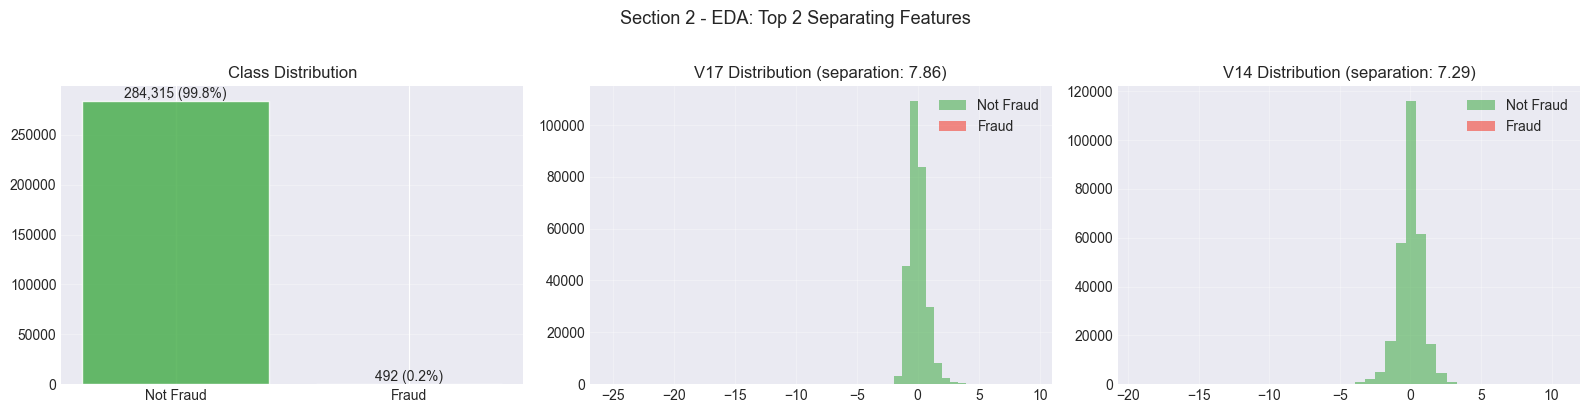

Imbalance ratio        : 577.9:1
Baseline AUPRC (random): 0.0017
Baseline ROC-AUC       : 0.5000 (always)
AUPRC is 579x harder to inflate — use it as primary metric


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar([NEGATIVE_LABEL, POSITIVE_LABEL], counts.values,
            color=[COLORS["good"], COLORS["val"]], alpha=0.85, edgecolor="white")
for i, v in enumerate(counts.values):
    label = f"{v:,} ({v/len(df):.1%})"
    axes[0].text(i, v + counts.max()*0.01, label, ha="center", fontsize=10)
axes[0].set_title("Class Distribution"); axes[0].grid(alpha=0.3, axis="y")

numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET_COL]
sep_scores = {}
for col in numeric_cols:
    m0 = df[df[TARGET_COL]==0][col].mean()
    m1 = df[df[TARGET_COL]==1][col].mean()
    s  = df[col].std()
    if s > 0: sep_scores[col] = abs(m1 - m0) / s
top_features = sorted(sep_scores, key=sep_scores.get, reverse=True)[:2]

for ax, feat in zip(axes[1:], top_features):
    ax.hist(df[df[TARGET_COL]==0][feat], bins=40, alpha=0.6, color=COLORS["good"], label=NEGATIVE_LABEL)
    ax.hist(df[df[TARGET_COL]==1][feat], bins=40, alpha=0.6, color=COLORS["val"],  label=POSITIVE_LABEL)
    ax.set_title(f"{feat} Distribution (separation: {sep_scores[feat]:.2f})")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Section 2 - EDA: Top 2 Separating Features", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Baseline AUPRC context — critical for imbalanced datasets
_baseline_auprc = y.mean()
print(f"Imbalance ratio        : {(1-_baseline_auprc)/_baseline_auprc:.1f}:1")
print(f"Baseline AUPRC (random): {_baseline_auprc:.4f}")
print(f"Baseline ROC-AUC       : 0.5000 (always)")
print(f"AUPRC is {1/_baseline_auprc:.0f}x harder to inflate — use it as primary metric")


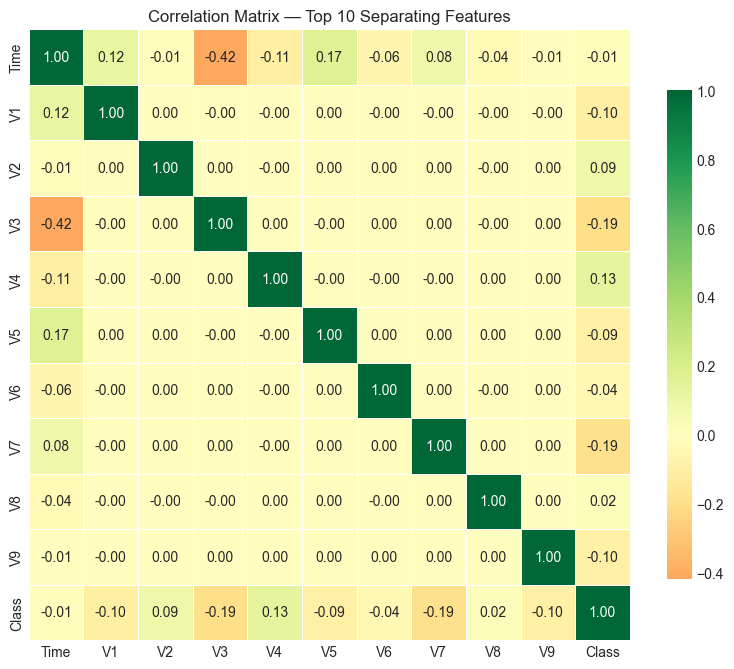

In [11]:
# Show top separating features in heatmap — scale count to readability
# Rule: annotate if <=20 features, skip annotation if more (too crowded)
_heatmap_n   = min(len(sep_scores), max(10, int(n_features * 0.15)))
_heatmap_cols = list(sep_scores.keys())[:_heatmap_n] + [TARGET_COL]
_annot       = _heatmap_n <= 20
_cell_size   = 0.55  # inches per cell
_fig_size    = max(8, _heatmap_n * _cell_size)

fig, ax = plt.subplots(figsize=(_fig_size, _fig_size * 0.85))
sns.heatmap(df[_heatmap_cols].corr(), annot=_annot, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title(f"Correlation Matrix — Top {_heatmap_n} Separating Features", fontsize=12)
plt.tight_layout(); plt.show()
if not _annot:
    print(f"Note: annotations hidden for readability ({_heatmap_n} features)")


---
## Section 3 — 🔴 Baseline: Detect Overfit

Intentionally overfit model to establish a baseline.
Overfit is detected by the **Train AUC vs Val AUC gap**.


[100]	training's auc: 0.539907	valid_1's auc: 0.489714
[200]	training's auc: 0.773981	valid_1's auc: 0.745683
[300]	training's auc: 0.773981	valid_1's auc: 0.745683
[400]	training's auc: 0.773981	valid_1's auc: 0.745683
[500]	training's auc: 0.773981	valid_1's auc: 0.745683
  Baseline (overfit)             ROC-AUC=0.7290  AUPRC=0.1847  Gap(roc)=-0.0146  🟢 HEALTHY


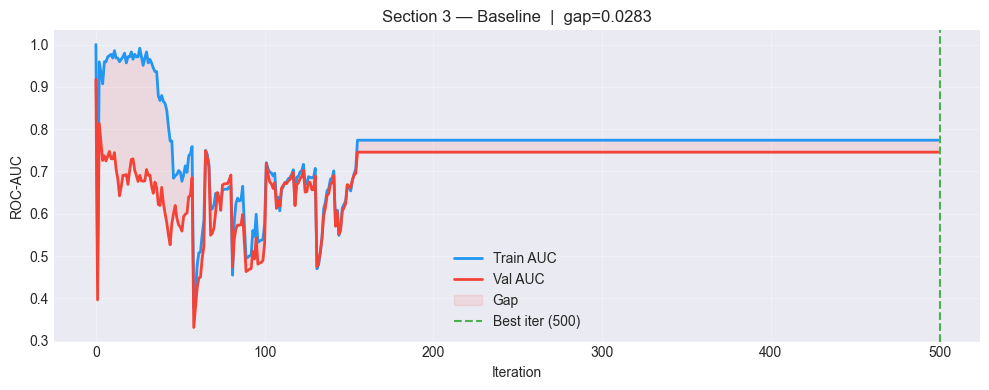

In [12]:
clf_baseline = LGBMClassifier(
    objective='binary',
    metric='auc',
    num_leaves=400,        # too high
    max_depth=-1,          # no limit
    min_child_samples=5,   # too low
    learning_rate=0.1,
    n_estimators=500,
    verbosity=-1,
    random_state=RANDOM_STATE,
)

clf_baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='auc',  # intentional — baseline always uses ROC-AUC
    callbacks=[log_evaluation(100)],
)
res_baseline = evaluate(clf_baseline, 'Baseline (overfit)')
plot_curves(clf_baseline, 'Section 3 — Baseline')

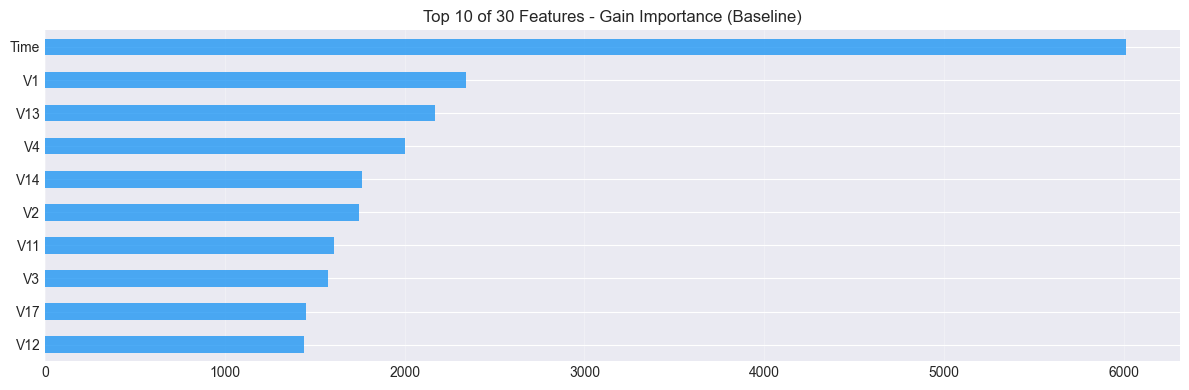

Healthy spread. Top: Time (14%)


In [13]:
fi = pd.Series(clf_baseline.feature_importances_, index=FEATURES).sort_values(ascending=False)

_fi_show = _chart_top_n
_fig_h   = max(4, _fi_show * 0.4)
fig, ax = plt.subplots(figsize=(12, _fig_h))
fi.head(_fi_show).sort_values().plot(kind="barh", ax=ax, color=COLORS["train"], alpha=0.8)
ax.set_title(f"Top {_fi_show} of {n_features} Features - Gain Importance (Baseline)", fontsize=12)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

top_pct = fi.iloc[0] / fi.sum()
if top_pct > 0.5:
    print(f"WARNING: {fi.index[0]} = {top_pct:.0%} — possible DATA LEAKAGE")
else:
    print(f"Healthy spread. Top: {fi.index[0]} ({top_pct:.0%})")


---
## Section 4 — 📊 Quick Gain Importance

Fast gain importance on the **baseline model** — purpose is early leakage detection only.
Permutation + SHAP run in **Section 7** on  where results are meaningful.


### Method 1 — Gain Importance

Active features: 30 of 30


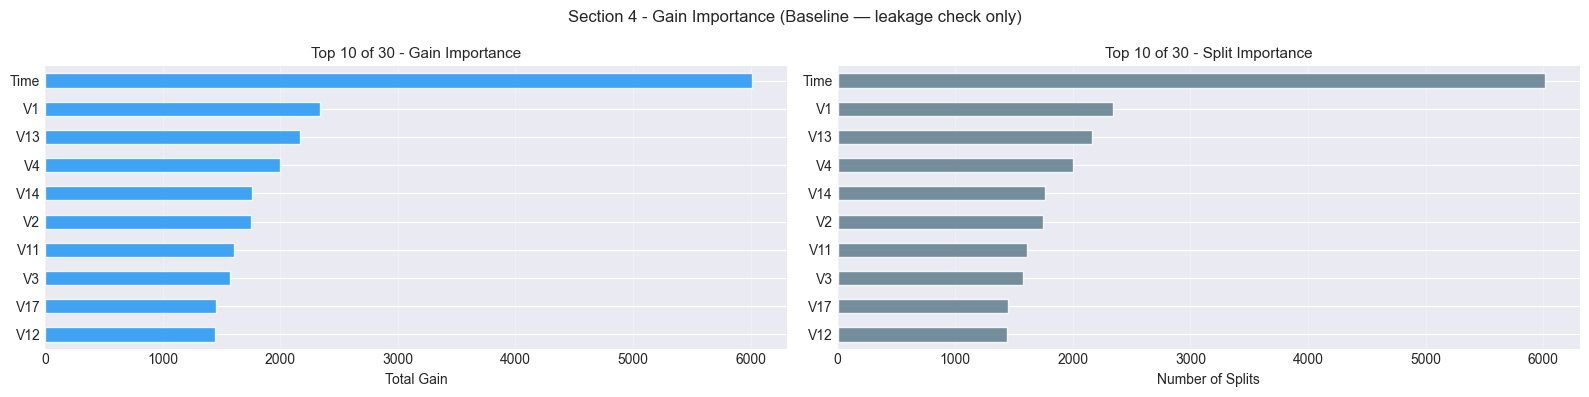

Healthy spread. Top: Time (14%)


In [14]:
importance_model = clf_baseline

fi_gain = pd.Series(
    importance_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)

# Pre-filter zero-importance features
zero_importance = fi_gain[fi_gain == 0].index.tolist()
active_features = fi_gain[fi_gain > 0].index.tolist()
n_active = len(active_features)
if zero_importance:
    print(f"Pre-filter: {len(zero_importance)} zero-importance features dropped")
print(f"Active features: {n_active} of {n_features}")

_show = min(_chart_top_n, n_active)
_fig_h = max(4, _show * 0.4)
fig, axes = plt.subplots(1, 2, figsize=(16, _fig_h))

fi_gain.head(_show).sort_values().plot(
    kind="barh", ax=axes[0], color=COLORS["train"], alpha=0.85, edgecolor="white")
axes[0].set_title(f"Top {_show} of {n_features} - Gain Importance", fontsize=11)
axes[0].set_xlabel("Total Gain"); axes[0].grid(alpha=0.3, axis="x")

# Split importance for comparison
fi_split = pd.Series(
    importance_model.booster_.feature_importance(importance_type="split"), index=FEATURES
).sort_values(ascending=False)
fi_split.head(_show).sort_values().plot(
    kind="barh", ax=axes[1], color=COLORS["neutral"], alpha=0.85, edgecolor="white")
axes[1].set_title(f"Top {_show} of {n_features} - Split Importance", fontsize=11)
axes[1].set_xlabel("Number of Splits"); axes[1].grid(alpha=0.3, axis="x")

plt.suptitle("Section 4 - Gain Importance (Baseline — leakage check only)", fontsize=12)
plt.tight_layout(); plt.show()

top_pct = fi_gain.iloc[0] / fi_gain.sum()
if top_pct > 0.5:
    print(f"WARNING: {fi_gain.index[0]} = {top_pct:.0%} — possible DATA LEAKAGE")
else:
    print(f"Healthy spread. Top: {fi_gain.index[0]} ({top_pct:.0%})")


---
## Section 5 — 🛠️ Fix #1: Regularization

| Parameter | Overfit | Fixed | Effect |
|-----------|---------|-------|--------|
|  | 400 | **31** | Simpler trees |
|  | -1 | **6** | Depth ceiling |
|  | 5 | **100** | More samples per leaf |
|  (L1) | 0 | **0.1** | Sparsity penalty |
|  (L2) | 0 | **0.1** | Weight penalty |
|  | 0 | **0.01** | Skip low-gain splits |


[100]	training's auc: 0.999995	valid_1's auc: 0.937281
[200]	training's auc: 1	valid_1's auc: 0.956728
[300]	training's auc: 1	valid_1's auc: 0.962765
[400]	training's auc: 1	valid_1's auc: 0.962765
[500]	training's auc: 1	valid_1's auc: 0.962765
  Regularization                 ROC-AUC=0.9628  AUPRC=0.7535  Gap(roc)=0.0372  🟡 MODERATE
Gap reduced by 0%  (-0.0146 -> 0.0372)


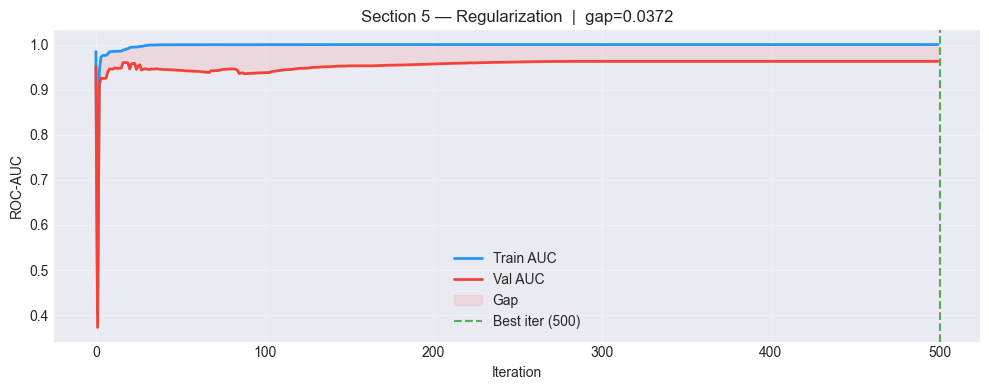

Sweeping num_leaves: [15, 31, 63, 127, 255]
  num_leaves=15     roc_auc=0.9676  auprc=0.7696  gap=0.0324  🟡
  num_leaves=31     roc_auc=0.9628  auprc=0.7535  gap=0.0372  🟡
  num_leaves=63     roc_auc=0.9631  auprc=0.7441  gap=0.0369  🟡
  num_leaves=127    roc_auc=0.9631  auprc=0.7441  gap=0.0369  🟡
  num_leaves=255    roc_auc=0.9631  auprc=0.7441  gap=0.0369  🟡
Best num_leaves = 15 — updating clf_reg
  Regularization (num_leaves=15) ROC-AUC=0.9676  AUPRC=0.7696  Gap(roc)=0.0324  🟡 MODERATE


In [15]:
clf_reg = LGBMClassifier(
    objective="binary",
    metric=LGBM_METRIC,
    num_leaves=31,         # starting point — swept below
    max_depth=6,
    min_child_samples=100,
    reg_alpha=0.1,
    reg_lambda=0.1,
    min_split_gain=0.01,
    learning_rate=0.05,
    n_estimators=500,
    verbosity=-1,
    random_state=RANDOM_STATE,
)
clf_reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric=LGBM_METRIC,
    callbacks=[log_evaluation(100)],
)
res_reg = evaluate(clf_reg, "Regularization")
_tmp_bg = res_baseline["gap"]
_tmp_rg = res_reg["gap"]
reduction = (1 - _tmp_rg / _tmp_bg) * 100 if _tmp_bg > 0 else 0
print(f"Gap reduced by {reduction:.0f}%  ({_tmp_bg:.4f} -> {_tmp_rg:.4f})")
plot_curves(clf_reg, "Section 5 — Regularization")

# Sweep num_leaves and apply best to clf_reg
print(f"Sweeping num_leaves: {_nl_sweep}")
nl_results = {}
for nl in _nl_sweep:
    clf = LGBMClassifier(**{**clf_reg.get_params(), "num_leaves": nl, "verbosity": -1})
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)],
            eval_metric=LGBM_METRIC, callbacks=[log_evaluation(-1)])
    va_s = score(y_val,   get_proba(clf, X_val))
    tr_s = score(y_train, get_proba(clf, X_train))
    g    = tr_s[OVERFITTING_METRIC] - va_s[OVERFITTING_METRIC]
    nl_results[nl] = {"val": va_s[OVERFITTING_METRIC], "gap": g}
    print(f"  num_leaves={nl:<5}  roc_auc={va_s[OVERFITTING_METRIC]:.4f}  auprc={va_s[EVALUATION_METRIC]:.4f}  gap={g:.4f}  {gap_flag(g)}")

best_nl = max(nl_results, key=lambda k: nl_results[k]["val"])
print(f"Best num_leaves = {best_nl} — updating clf_reg")

# Rebuild clf_reg with best num_leaves so downstream models inherit it
clf_reg = LGBMClassifier(**{**clf_reg.get_params(), "num_leaves": best_nl})
clf_reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric=LGBM_METRIC,
    callbacks=[log_evaluation(-1)],
)
res_reg = evaluate(clf_reg, f"Regularization (num_leaves={best_nl})")


---
## Section 6 — 🛠️ Fix #2 + #3: Subsampling + Early Stopping

Combined into one section to build  efficiently.
 is needed for reliable feature importance in Section 7.

- **** — fraction of rows per tree
- **** — fraction of features per tree
- **Early stopping** — finds optimal number of trees automatically


Sweeping subsample + colsample_bytree...


  subsample=0.4  colsample=0.6  roc_auc=0.9823  auprc=0.8117  gap=0.0177  🟢
  subsample=0.4  colsample=0.8  roc_auc=0.9828  auprc=0.8230  gap=0.0172  🟢
  subsample=0.4  colsample=1.0  roc_auc=0.9849  auprc=0.8236  gap=0.0151  🟢
  subsample=0.6  colsample=0.6  roc_auc=0.9838  auprc=0.8296  gap=0.0162  🟢
  subsample=0.6  colsample=0.8  roc_auc=0.9829  auprc=0.7959  gap=0.0171  🟢
  subsample=0.6  colsample=1.0  roc_auc=0.9823  auprc=0.8161  gap=0.0177  🟢
  subsample=0.8  colsample=0.6  roc_auc=0.9841  auprc=0.7898  gap=0.0159  🟢
  subsample=0.8  colsample=0.8  roc_auc=0.9849  auprc=0.8362  gap=0.0151  🟢
  subsample=0.8  colsample=1.0  roc_auc=0.9660  auprc=0.8190  gap=0.0340  🟡
  subsample=1.0  colsample=0.6  roc_auc=0.9865  auprc=0.8225  gap=0.0135  🟢
  subsample=1.0  colsample=0.8  roc_auc=0.9837  auprc=0.8303  gap=0.0163  🟢
  subsample=1.0  colsample=1.0  roc_auc=0.9676  auprc=0.7696  gap=0.0324  🟡
Best: subsample=1.0  colsample_bytree=0.6
  Subsampling (1.0/0.6)          ROC-AUC=0.986

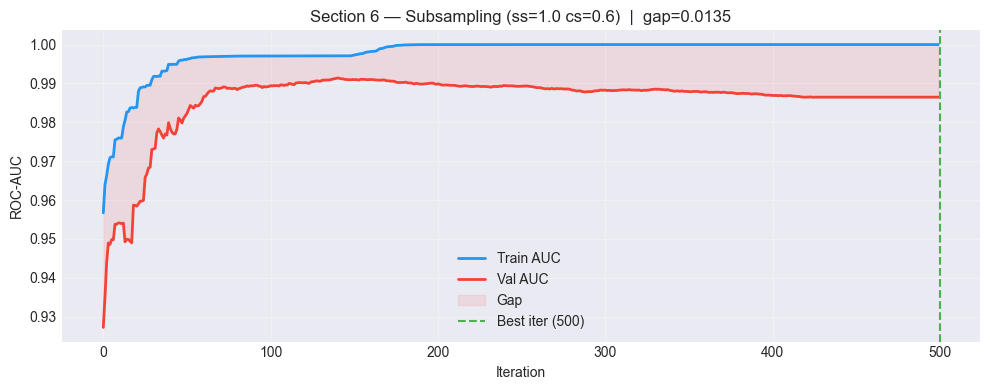

In [16]:
print("Sweeping subsample + colsample_bytree...")
sub_results = {}
for ss in [0.4, 0.6, 0.8, 1.0]:
    for cs in [0.6, 0.8, 1.0]:
        clf = LGBMClassifier(**{**clf_reg.get_params(),
                                "subsample": ss,
                                "subsample_freq": 1 if ss < 1.0 else 0,
                                "colsample_bytree": cs,
                                "verbosity": -1})
        clf.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                eval_metric=LGBM_METRIC, callbacks=[log_evaluation(-1)])
        va_s = score(y_val,   get_proba(clf, X_val))
        tr_s = score(y_train, get_proba(clf, X_train))
        g    = tr_s[OVERFITTING_METRIC] - va_s[OVERFITTING_METRIC]
        key  = (ss, cs)
        sub_results[key] = {"val": va_s[OVERFITTING_METRIC], "gap": g}
        print(f"  subsample={ss:.1f}  colsample={cs:.1f}  roc_auc={va_s[OVERFITTING_METRIC]:.4f}  auprc={va_s[EVALUATION_METRIC]:.4f}  gap={g:.4f}  {gap_flag(g)}")

best_key = max(sub_results, key=lambda k: sub_results[k]["val"])
best_ss, best_cs = best_key
print(f"Best: subsample={best_ss}  colsample_bytree={best_cs}")

clf_sub = LGBMClassifier(**{**clf_reg.get_params(),
                            "subsample": best_ss,
                            "subsample_freq": 1 if best_ss < 1.0 else 0,
                            "colsample_bytree": best_cs,
                            "verbosity": -1})
clf_sub.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            eval_metric=LGBM_METRIC, callbacks=[log_evaluation(-1)])
res_sub = evaluate(clf_sub, f"Subsampling ({best_ss}/{best_cs})")
plot_curves(clf_sub, f"Section 6 — Subsampling (ss={best_ss} cs={best_cs})")


Training until validation scores don't improve for 50 rounds
[100]	training's auc: 0.99707	valid_1's auc: 0.989225
Early stopping, best iteration is:
[141]	training's auc: 0.997093	valid_1's auc: 0.991394
Best iteration : 141
Trees saved    : 1859
  Early Stopping                 ROC-AUC=0.9914  AUPRC=0.8013  Gap(roc)=0.0057  🟢 HEALTHY


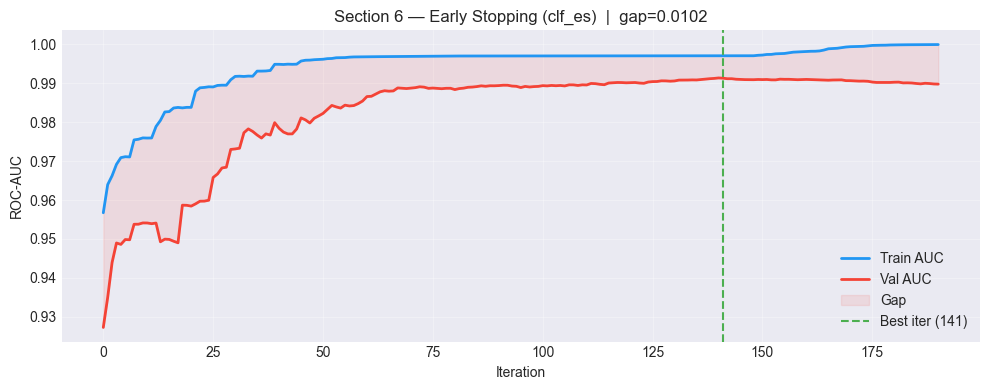

In [17]:
clf_es = LGBMClassifier(
    **{**clf_sub.get_params(),
       'n_estimators': 2000,
       'metric': LGBM_METRIC,
       'verbosity': -1}
)

clf_es.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric=LGBM_METRIC,
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=True),
        log_evaluation(100),
    ],
)

print(f'Best iteration : {clf_es.best_iteration_}')
print(f'Trees saved    : {2000 - clf_es.best_iteration_}')
res_es = evaluate(clf_es, 'Early Stopping')
plot_curves(clf_es, 'Section 6 — Early Stopping (clf_es)')


---
## Section 7 — 📊 Full Feature Importance

 is a properly regularised model — permutation and SHAP values are reliable here.
Running on the overfit baseline gives near-zero values for everything.

| Method | Speed | Reliability | Shows Direction |
|--------|-------|-------------|------------------|
| Gain | Fast | Medium | No |
| Permutation | Medium | High | No |
| SHAP | Slow | Very High | Yes |

At the end: **evidence-based feature removal** — only drops features all 3 methods agree are useless.


### Method 2 — Permutation Importance
Shuffles each feature and measures AUC drop on .


Active features on clf_es: 30 of 30
Permutation importance: 30 features x 19 repeats...


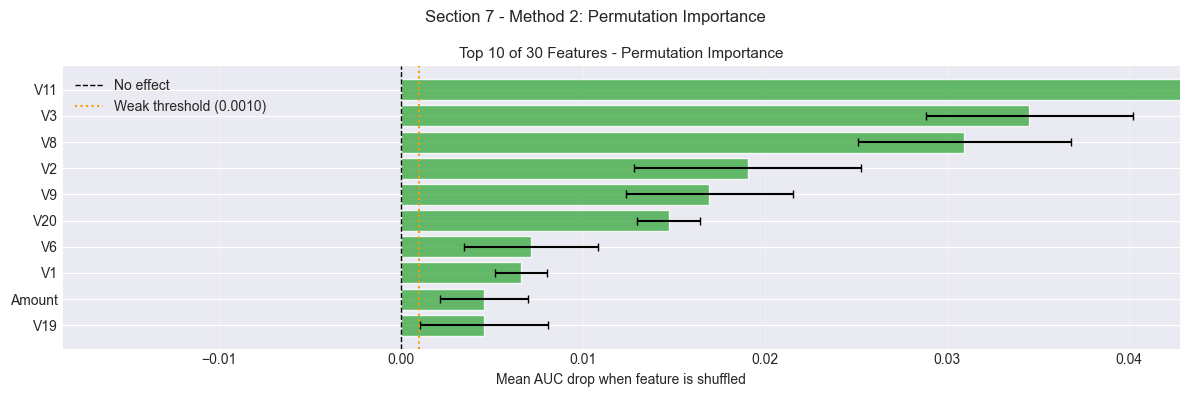

Top feature: V11 (drop=0.0720)
Weak features: 18 — ['V13', 'V16', 'V28', 'Time', 'V4', 'V18', 'V12', 'V24', 'V22', 'V25']...


In [18]:
# Use clf_es — regularised model gives meaningful permutation importance
importance_model = clf_es

# Recompute active features on clf_es (may differ from baseline)
fi_gain_es = pd.Series(
    importance_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)
zero_importance = fi_gain_es[fi_gain_es == 0].index.tolist()
active_features = fi_gain_es[fi_gain_es > 0].index.tolist()
n_active = len(active_features)
print(f"Active features on clf_es: {n_active} of {n_features}")

print(f"Permutation importance: {n_active} features x {_perm_reps} repeats...")

X_val_active = X_val[active_features]
perm_result  = permutation_importance(
    importance_model, X_val_active, y_val,
    n_repeats=_perm_reps, scoring="roc_auc",  # always roc_auc — stable for feature ranking
    random_state=RANDOM_STATE, n_jobs=-1
)

fi_perm_active = pd.DataFrame({
    "importance": perm_result.importances_mean,
    "std":        perm_result.importances_std,
}, index=active_features)

if zero_importance:
    fi_perm_zeros = pd.DataFrame({"importance": 0.0, "std": 0.0}, index=zero_importance)
else:
    fi_perm_zeros = pd.DataFrame(columns=["importance", "std"])

fi_perm = pd.concat([fi_perm_active, fi_perm_zeros]).sort_values("importance", ascending=False)

_show   = min(_chart_top_n, len(fi_perm))
_fig_h  = max(4, _show * 0.4)
_top_df = fi_perm.head(_show).sort_values("importance")

_x_max = max(np.percentile(fi_perm["importance"].clip(lower=0), 95) * 1.3, 0.002)
_x_min = min(fi_perm["importance"].min() - 0.001, -0.001)
_perm_threshold_chart = 0.001  # roc_auc drop — local to this chart

bar_colors = [
    COLORS["good"] if v > 0.001 else (COLORS["warn"] if v > 0 else COLORS["val"])
    for v in _top_df["importance"]
]
fig, ax = plt.subplots(figsize=(12, _fig_h))
ax.barh(_top_df.index, _top_df["importance"],
        xerr=_top_df["std"], color=bar_colors, alpha=0.85, edgecolor="white", capsize=3)
ax.axvline(0,     color="black",        lw=1,   linestyle="--", label="No effect")
ax.axvline(_perm_threshold_chart, color=COLORS["warn"], lw=1.5, linestyle=":", label=f"Weak threshold ({_perm_threshold_chart:.4f})")
ax.set_xlim(_x_min, _x_max)
ax.set_title(f"Top {_show} of {n_features} Features - Permutation Importance", fontsize=11)
ax.set_xlabel("Mean AUC drop when feature is shuffled")
ax.legend(); ax.grid(alpha=0.3, axis="x")
plt.suptitle("Section 7 - Method 2: Permutation Importance", fontsize=12)
plt.tight_layout(); plt.show()

_top_imp  = fi_perm["importance"].max()
_top_feat = fi_perm["importance"].idxmax()
_weak     = fi_perm[fi_perm["importance"] < 0.001].index.tolist()
print(f"Top feature: {_top_feat} (drop={_top_imp:.4f})")
_wk = str(_weak[:10]) + ("..." if len(_weak) > 10 else "")
print(f"Weak features: {len(_weak)} — {_wk}")


### Method 3 — SHAP Values
- **Bar chart** = mean importance
- **Dot chart** = direction (right = pushes toward positive class)


In [19]:
print(f"SHAP: {n_active} features on {_shap_rows:,} rows (full val set)...")

X_shap_full = X_val[active_features]  # full val set, no sampling
explainer   = shap.TreeExplainer(importance_model)
shap_values = explainer.shap_values(X_shap_full)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

fi_shap_active = pd.Series(
    np.abs(shap_values).mean(axis=0), index=active_features
).sort_values(ascending=False)
fi_shap_zeros = pd.Series(0.0, index=zero_importance) if zero_importance else pd.Series(dtype=float)
fi_shap = pd.concat([fi_shap_active, fi_shap_zeros]).sort_values(ascending=False)

print(f"SHAP done. Top 10:")
print(fi_shap.head(10).to_string())


SHAP: 30 features on 42,721 rows (full val set)...
SHAP done. Top 10:
V23       0.720501
V26       0.427701
V3        0.215483
Amount    0.205119
V9        0.182041
V27       0.172894
V11       0.164334
V8        0.151493
V2        0.137330
V7        0.121545


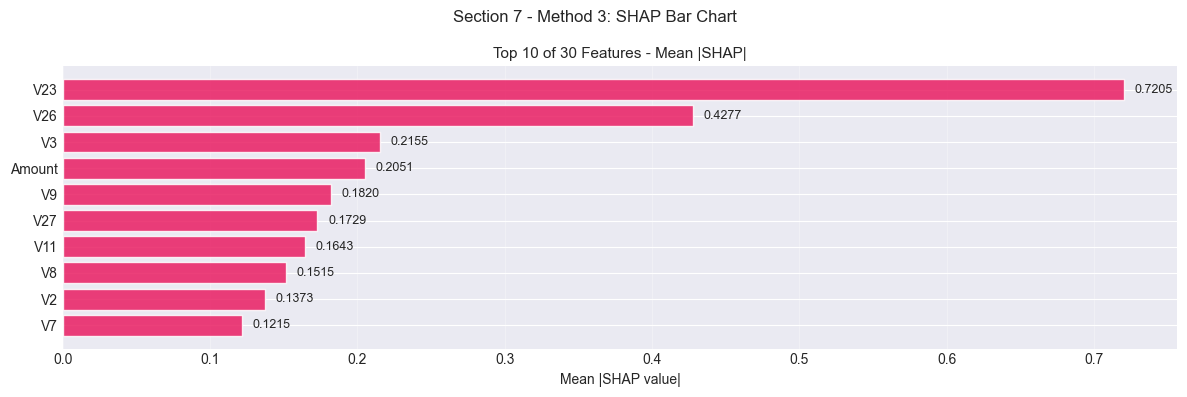

In [20]:
_show  = min(_chart_top_n, n_active)
_fig_h = max(4, _show * 0.4)
fi_shap_top = fi_shap.head(_show).sort_values()

fig, ax = plt.subplots(figsize=(12, _fig_h))
bars = ax.barh(fi_shap_top.index, fi_shap_top.values,
               color=COLORS["shap"], alpha=0.85, edgecolor="white")
for bar, val in zip(bars, fi_shap_top.values):
    ax.text(val + fi_shap_top.max()*0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_title(f"Top {_show} of {n_features} Features - Mean |SHAP|", fontsize=11)
ax.set_xlabel("Mean |SHAP value|")
ax.grid(alpha=0.3, axis="x")
plt.suptitle("Section 7 - Method 3: SHAP Bar Chart", fontsize=12)
plt.tight_layout(); plt.show()


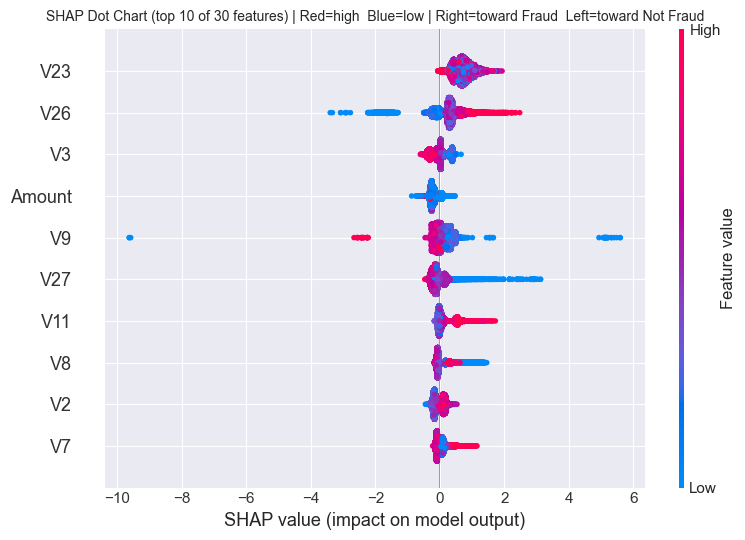

In [21]:
_show  = min(_chart_top_n, n_active)
_fig_h = max(4, _show * 0.4)
plt.figure(figsize=(12, _fig_h))
shap.summary_plot(shap_values, X_shap_full, max_display=_show, show=False)
plt.title(
    f"SHAP Dot Chart (top {_show} of {n_features} features) | "
    f"Red=high  Blue=low | "
    f"Right=toward {POSITIVE_LABEL}  Left=toward {NEGATIVE_LABEL}",
    fontsize=10
)
plt.tight_layout(); plt.show()


### All 3 Methods — Rank Comparison


Top 10 of 30 active features ranked across all 3 methods:
        Gain Rank  Permutation Rank  SHAP Rank  Mean Rank Consensus
V3              9                 2          3   4.666667    Strong
Amount          4                 9          4   5.666667    Strong
V9             13                 5          5   7.666667      Good
V11            22                 1          7  10.000000      Good
V8             21                 3          8  10.666667      Good
V15            12                11         11  11.333333      Good
V26             5                28          2  11.666667      Good
V28             3                15         21  13.000000      Good
V20            13                 6         22  13.666667      Good
V1             16                 8         17  13.666667      Good


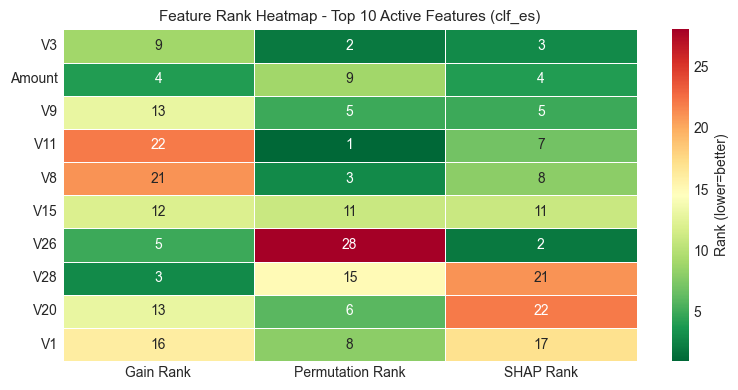

In [22]:
# Use fi_gain_es (from clf_es) for consistent ranking — not fi_gain (from baseline)
fi_gain_for_rank = fi_gain_es[active_features]

rank_df = pd.DataFrame({
    "Gain Rank"       : fi_gain_for_rank.rank(ascending=False).astype(int),
    "Permutation Rank": fi_perm_active["importance"].rank(ascending=False).astype(int),
    "SHAP Rank"       : fi_shap_active.rank(ascending=False).astype(int),
})
rank_df["Mean Rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("Mean Rank")
rank_df["Consensus"] = rank_df["Mean Rank"].apply(
    lambda r: "Strong" if r <= n_active*0.2 else ("Good" if r <= n_active*0.5 else "Weak"))

_show  = min(_chart_top_n, n_active)
_fig_h = max(4, _show * 0.4)
print(f"Top {_show} of {n_active} active features ranked across all 3 methods:")
print(rank_df.head(_show).to_string())

fig, ax = plt.subplots(figsize=(8, _fig_h))
top_rank = rank_df.head(_show)[["Gain Rank","Permutation Rank","SHAP Rank"]]
_annot = _show <= 40
sns.heatmap(top_rank, annot=_annot, fmt="d", cmap="RdYlGn_r",
            ax=ax, linewidths=0.5, cbar_kws={"label": "Rank (lower=better)"})
ax.set_title(f"Feature Rank Heatmap - Top {_show} Active Features (clf_es)", fontsize=11)
plt.tight_layout(); plt.show()


### Evidence-Based Feature Removal

A feature is removed only if **all 3 methods agree** it is useless:
- Gain = 0 — model never used it
- Permutation < 0.001 — shuffling it does not hurt AUC
- SHAP < 1% of top feature — negligible impact on predictions

Borderline features (2 of 3 weak) are kept but flagged.
If removing features hurts AUC, the full set is automatically restored.


In [23]:
# Thresholds — data-driven
shap_threshold = fi_shap.max() * 0.01
# Scale perm threshold: for AUPRC, baseline is fraud_rate not 0.5
# A 0.001 drop in AUPRC matters more when baseline is 0.002 than when it is 0.5
perm_threshold = 0.001  # ROC-AUC scale — drop in AUC when feature shuffled
gain_threshold = 0

useless    = []
borderline = []

for feat in FEATURES:
    gain_weak = fi_gain_es.get(feat, 0) <= gain_threshold
    perm_weak = fi_perm.loc[feat, "importance"] < perm_threshold if feat in fi_perm.index else True
    shap_weak = fi_shap.get(feat, 0) < shap_threshold
    n_flags   = sum([gain_weak, perm_weak, shap_weak])
    if n_flags == 3:
        useless.append(feat)
    elif n_flags == 2:
        borderline.append(feat)

kept_features = [f for f in FEATURES if f not in useless]

print(f"Feature audit:")
print(f"  Total      : {len(FEATURES)}")
print(f"  Useless    : {len(useless)} — {useless}")
print(f"  Borderline : {len(borderline)} — {borderline}")
print(f"  Kept       : {len(kept_features)}")
print(f"Thresholds: SHAP={shap_threshold:.6f}  Perm={perm_threshold}  Gain={gain_threshold}")


Feature audit:
  Total      : 30
  Useless    : 0 — []
  Borderline : 0 — []
  Kept       : 30
Thresholds: SHAP=0.007205  Perm=0.001  Gain=0


In [24]:
# Compare full vs cleaned using OVERFITTING_METRIC (roc_auc) for revert decision
X_train_kept = X_train[kept_features]
X_val_kept   = X_val[kept_features]
X_test_kept  = X_test[kept_features]

# Use same n_estimators as clf_es best iteration for fair comparison
clf_kept = LGBMClassifier(**{**clf_es.get_params(),
                             "n_estimators": clf_es.best_iteration_ or 300,
                             "verbosity": -1})
clf_kept.fit(X_train_kept, y_train,
             eval_set=[(X_val_kept, y_val)],
             eval_metric=LGBM_METRIC,
             callbacks=[log_evaluation(-1)])

full_s = score(y_val,   get_proba(importance_model, X_val))
kept_s = score(y_val,   get_proba(clf_kept, X_val_kept))
full_tr_s = score(y_train, get_proba(importance_model, X_train))
kept_tr_s = score(y_train, get_proba(clf_kept, X_train_kept))

full_val = full_s[OVERFITTING_METRIC]
kept_val = kept_s[OVERFITTING_METRIC]
full_tr  = full_tr_s[OVERFITTING_METRIC]
kept_tr  = kept_tr_s[OVERFITTING_METRIC]

print(f"All  {len(FEATURES)} features  roc_auc={full_val:.4f}  auprc={full_s[EVALUATION_METRIC]:.4f}  Gap={full_tr-full_val:.4f}")
print(f"Kept {len(kept_features)} features  roc_auc={kept_val:.4f}  auprc={kept_s[EVALUATION_METRIC]:.4f}  Gap={kept_tr-kept_val:.4f}")

diff = kept_val - full_val
if len(useless) == 0:
    print("No useless features found — keeping full feature set")
elif diff >= -0.002:
    print(f"Dropped {len(useless)} useless features. roc_auc difference: {diff:+.4f}")
else:
    print(f"roc_auc dropped {abs(diff):.4f} — reverting to full feature set")
    kept_features = list(FEATURES)
    X_train_kept  = X_train.copy()
    X_val_kept    = X_val.copy()
    X_test_kept   = X_test.copy()
    kept_val = full_val; kept_tr = full_tr
    kept_s   = full_s;   kept_tr_s = full_tr_s

# Update for all subsequent sections
X_train  = X_train_kept.copy()
X_val    = X_val_kept.copy()
X_test   = X_test_kept.copy()
FEATURES = kept_features
print(f"Sections 8-11 will train on {len(FEATURES)} features")

# _te_s uses X_test_kept which is either cleaned or reverted to full — correct either way
_te_s = score(y_test, get_proba(clf_kept, X_test_kept))
all_experiment_results[f"Cleaned Features ({len(kept_features)})"] = {
    "train"       : kept_tr,
    "val"         : kept_s[EVALUATION_METRIC],
    "test"        : _te_s[EVALUATION_METRIC],
    "val_roc_auc" : kept_s["roc_auc"],
    "val_auprc"   : kept_s["auprc"],
    "test_roc_auc": _te_s["roc_auc"],
    "test_auprc"  : _te_s["auprc"],
    "gap"         : kept_tr - kept_val,
}


All  30 features  roc_auc=0.9914  auprc=0.8013  Gap=0.0057
Kept 30 features  roc_auc=0.9914  auprc=0.8013  Gap=0.0057
No useless features found — keeping full feature set
Sections 8-11 will train on 30 features


---
## Section 8 — 🛠️ Fix #3: Class Imbalance

Runs on the **cleaned feature set** from Section 7.
Best strategy by F1 is auto-selected and passed into Optuna.


In [25]:
imb_results = {}
models_list  = []

strategies = [
    ("No correction",                       {}),
    (f"scale_pos_weight={SCALE_POS_WEIGHT}", {"scale_pos_weight": SCALE_POS_WEIGHT}),
    ("is_unbalance=True",                   {"is_unbalance": True}),
]

base = {**clf_es.get_params(), "n_estimators": clf_es.best_iteration_ or 300, "verbosity": -1}

print("  {:<28} {:>8} {:>7} {:>10} {:>8} {:>6}".format("Strategy","ROC-AUC","AUPRC","Precision","Recall","F1"))
print("-" * 72)

for name, extra in strategies:
    clf   = LGBMClassifier(**{**base, **extra})
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)],
            eval_metric=LGBM_METRIC, callbacks=[log_evaluation(-1)])
    prob  = get_proba(clf, X_val)
    preds = (prob > 0.5).astype(int)
    va_s  = score(y_val, prob)
    r = {
        "roc_auc": va_s["roc_auc"],
        "auprc"  : va_s["auprc"],
        "prec"   : precision_score(y_val, preds, zero_division=0),
        "rec"    : recall_score(y_val, preds, zero_division=0),
        "f1"     : f1_score(y_val, preds, zero_division=0),
        "preds"  : preds,
    }
    r["prob"] = prob
    imb_results[name] = r
    models_list.append((name, preds))
    _roc = r["roc_auc"]; _apr = r["auprc"]
    _pre = r["prec"]; _rec = r["rec"]; _f1 = r["f1"]
    print(f"  {name:<26} {_roc:>8.4f} {_apr:>7.4f} {_pre:>10.4f} {_rec:>8.4f} {_f1:>6.4f}")

# Auto-select by EVALUATION_METRIC (AUPRC) — best fraud detection performance
best_imb = max(imb_results, key=lambda k: imb_results[k][EVALUATION_METRIC])
print(f"")
print(f"Auto-selected by {EVALUATION_METRIC}: {best_imb}")


  Strategy                      ROC-AUC   AUPRC  Precision   Recall     F1
------------------------------------------------------------------------
  No correction                0.9914  0.8013     0.9333   0.7568 0.8358
  scale_pos_weight=577.9       0.9101  0.2092     0.1111   0.7568 0.1938
  is_unbalance=True            0.9283  0.2221     0.0898   0.8108 0.1617

Auto-selected by auprc: No correction


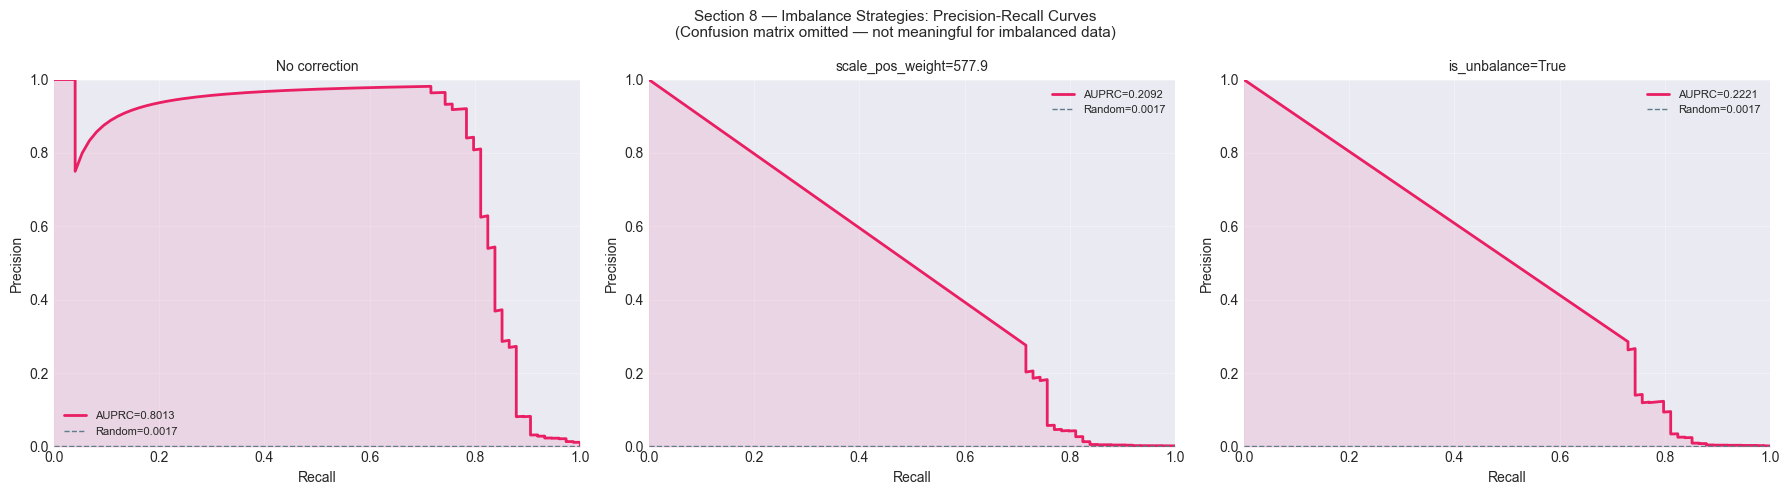

In [26]:
# Precision-Recall curves — reuse probabilities from cell above (no retraining)
# Confusion matrix is not meaningful for imbalanced data
fig, axes = plt.subplots(1, len(models_list), figsize=(6*len(models_list), 5))
if len(models_list) == 1: axes = [axes]

for ax, (name, _) in zip(axes, models_list):
    prob_pr  = imb_results[name]["prob"]
    p_vals, r_vals, _ = precision_recall_curve(y_val, prob_pr)
    ap       = average_precision_score(y_val, prob_pr)
    baseline = y_val.mean()
    ax.plot(r_vals, p_vals, color=COLORS["shap"], lw=2, label=f"AUPRC={ap:.4f}")
    ax.axhline(baseline, color=COLORS["neutral"], lw=1,
               linestyle="--", label=f"Random={baseline:.4f}")
    ax.fill_between(r_vals, p_vals, alpha=0.1, color=COLORS["shap"])
    ax.set_title(f"{name}", fontsize=10)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle(
    "Section 8 — Imbalance Strategies: Precision-Recall Curves\n"
    "(Confusion matrix omitted — not meaningful for imbalanced data)",
    fontsize=11
)
plt.tight_layout(); plt.show()


---
## Section 9 — 🔁 Cross Validation + Auto-Diagnosis

Runs on **cleaned features** with best imbalance strategy.
CV results auto-adjust Optuna search space in Section 10.


In [27]:
best_imb_params = next(params for name, params in strategies if name == best_imb)

cv_clf = LGBMClassifier(
    **{**clf_es.get_params(),
       **best_imb_params,
       "n_estimators": clf_es.best_iteration_ or 300,
       "verbosity": -1}
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_roc, fold_auprc, fold_gaps = [], [], []

print("  {:<6} {:>8} {:>7} {:>8}".format("Fold","ROC-AUC","AUPRC","Gap"))
print("-" * 34)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    Xtr, Xva = X.iloc[tr_idx][FEATURES], X.iloc[va_idx][FEATURES]
    ytr, yva = y.iloc[tr_idx],           y.iloc[va_idx]
    clf = LGBMClassifier(**cv_clf.get_params())
    clf.fit(Xtr, ytr, eval_set=[(Xva, yva)],
            eval_metric=LGBM_METRIC,
            callbacks=[early_stopping(50, verbose=False), log_evaluation(-1)])
    tr_s  = score(ytr, get_proba(clf, Xtr))
    va_s  = score(yva, get_proba(clf, Xva))
    gap   = tr_s[OVERFITTING_METRIC] - va_s[OVERFITTING_METRIC]
    fold_roc.append(va_s["roc_auc"])
    fold_auprc.append(va_s["auprc"])
    fold_gaps.append(gap)
    _roc = va_s["roc_auc"]; _apr = va_s["auprc"]
    print(f"Fold {fold+1}  {_roc:>8.4f} {_apr:>7.4f} {gap:>8.4f}  {gap_flag(gap)}")

cv_mean_roc   = np.mean(fold_roc)
cv_mean_auprc = np.mean(fold_auprc)
cv_std_roc    = np.std(fold_roc)
cv_std_auprc  = np.std(fold_auprc)
cv_mean_gap   = np.mean(fold_gaps)
print(f"")
print(f"CV Mean ROC-AUC : {cv_mean_roc:.4f} +/- {cv_std_roc:.4f}")
print(f"CV Mean AUPRC   : {cv_mean_auprc:.4f} +/- {cv_std_auprc:.4f}")
print(f"CV Mean Gap     : {cv_mean_gap:.4f}  {gap_flag(cv_mean_gap)}")

# Auto-diagnosis always uses OVERFITTING_METRIC (roc_auc) — stable for gap thresholds
fold_aucs      = fold_roc
cv_std_primary = cv_std_roc

print("")
print("AUTO-DIAGNOSIS:")
if cv_mean_gap > GAP_SEVERE:
    print(f"  🔴 CV gap {cv_mean_gap:.4f} SEVERE — tightening Optuna search space")
    AUTO_MIN_CHILD = 200; AUTO_REG_MIN = 0.5; AUTO_NL_MAX = 63; AUTO_SUBSAMPLE_MIN = 0.6
elif cv_mean_gap > GAP_MODERATE:
    print(f"  🟡 CV gap {cv_mean_gap:.4f} MODERATE — mild adjustment")
    AUTO_MIN_CHILD = 100; AUTO_REG_MIN = 0.1; AUTO_NL_MAX = 95; AUTO_SUBSAMPLE_MIN = 0.5
else:
    print(f"  🟢 CV gap {cv_mean_gap:.4f} HEALTHY")
    AUTO_MIN_CHILD = 20;  AUTO_REG_MIN = 0.0; AUTO_NL_MAX = 127; AUTO_SUBSAMPLE_MIN = 0.4

if cv_std_primary > 0.02:
    print(f"  ⚠️  High variance ({cv_std_primary:.4f}) — raising subsample floor")
    AUTO_SUBSAMPLE_MIN = max(AUTO_SUBSAMPLE_MIN, 0.6)

n_rows = len(X_train)
base_trials  = OPTUNA_TRIALS if n_rows > 500_000 else (max(OPTUNA_TRIALS, 75) if n_rows < 100_000 else max(OPTUNA_TRIALS, 50))
feat_penalty = max(1.0, n_features / 50)
AUTO_TRIALS  = int(base_trials * feat_penalty)
print(f"  ℹ️  {n_rows:,} rows — {AUTO_TRIALS} Optuna trials")

all_experiment_results["Cross Validation (mean)"] = {
    "train": None, "val": cv_mean_auprc,  # store AUPRC for reporting
    "val_roc_auc": cv_mean_roc, "val_auprc": cv_mean_auprc,
    "test": None, "gap": cv_mean_gap}


  Fold    ROC-AUC   AUPRC      Gap
----------------------------------
Fold 1    0.9649  0.7426   0.0286  🟡
Fold 2    0.9755  0.8309   0.0122  🟢
Fold 3    0.9921  0.8246   0.0079  🟢
Fold 4    0.9554  0.6848   0.0065  🟢
Fold 5    0.9715  0.7271   0.0234  🟡

CV Mean ROC-AUC : 0.9719 +/- 0.0122
CV Mean AUPRC   : 0.7620 +/- 0.0569
CV Mean Gap     : 0.0157  🟢

AUTO-DIAGNOSIS:
  🟢 CV gap 0.0157 HEALTHY
  ℹ️  199,364 rows — 50 Optuna trials


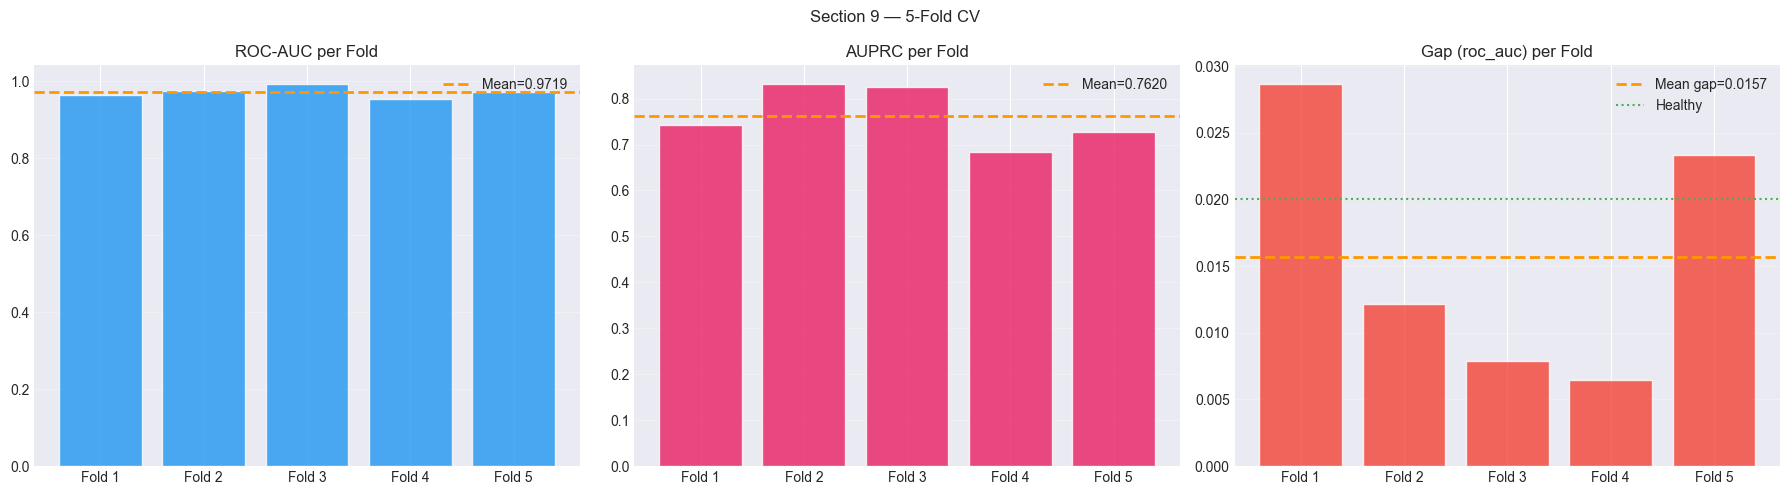

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(1,6), fold_roc, color=COLORS["train"], alpha=0.8, edgecolor="white")
axes[0].axhline(cv_mean_roc, color=COLORS["warn"], lw=2, linestyle="--",
                label=f"Mean={cv_mean_roc:.4f}")
axes[0].set_xticks(range(1,6)); axes[0].set_xticklabels([f"Fold {i}" for i in range(1,6)])
axes[0].set_title("ROC-AUC per Fold"); axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(range(1,6), fold_auprc, color=COLORS["shap"], alpha=0.8, edgecolor="white")
axes[1].axhline(cv_mean_auprc, color=COLORS["warn"], lw=2, linestyle="--",
                label=f"Mean={cv_mean_auprc:.4f}")
axes[1].set_xticks(range(1,6)); axes[1].set_xticklabels([f"Fold {i}" for i in range(1,6)])
axes[1].set_title("AUPRC per Fold"); axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

axes[2].bar(range(1,6), fold_gaps, color=COLORS["val"], alpha=0.8, edgecolor="white")
axes[2].axhline(cv_mean_gap, color=COLORS["warn"], lw=2, linestyle="--",
                label=f"Mean gap={cv_mean_gap:.4f}")
axes[2].axhline(GAP_MODERATE, color=COLORS["good"], lw=1.5, linestyle=":", label="Healthy")
axes[2].set_xticks(range(1,6)); axes[2].set_xticklabels([f"Fold {i}" for i in range(1,6)])
axes[2].set_title("Gap (roc_auc) per Fold"); axes[2].legend(); axes[2].grid(alpha=0.3, axis="y")

plt.suptitle("Section 9 — 5-Fold CV", fontsize=12)
plt.tight_layout(); plt.show()


---
## Section 10 — 🤖 Auto-Tune with Optuna

Combines **all fixes** on the **cleaned feature set**:
- Search space auto-tightened by CV diagnosis
- Imbalance strategy searched as a hyperparameter
- Trials auto-scaled by dataset size and feature count

> This is the definitive model.


In [29]:
def optuna_objective(trial):
    imb_strategy = trial.suggest_categorical("imb_strategy",
                                              ["scale_pos_weight", "is_unbalance", "none"])
    imb_params = {}
    if imb_strategy == "scale_pos_weight":
        imb_params = {"scale_pos_weight": SCALE_POS_WEIGHT}
    elif imb_strategy == "is_unbalance":
        imb_params = {"is_unbalance": True}

    params = {
        "objective"        : "binary",
        "metric"           : LGBM_METRIC,
        "verbosity"        : -1,
        "random_state"     : RANDOM_STATE,
        "num_leaves"       : trial.suggest_int("num_leaves", 15, AUTO_NL_MAX),
        "max_depth"        : trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", AUTO_MIN_CHILD, max(AUTO_MIN_CHILD+200, 500)),
        "reg_alpha"        : trial.suggest_float("reg_alpha", AUTO_REG_MIN, AUTO_REG_MIN+2.0),
        "reg_lambda"       : trial.suggest_float("reg_lambda", AUTO_REG_MIN, AUTO_REG_MIN+2.0),
        "min_split_gain"   : trial.suggest_float("min_split_gain", 0.0, 0.1),
        "subsample"        : trial.suggest_float("subsample", AUTO_SUBSAMPLE_MIN, 1.0),
        "subsample_freq"   : 1,
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.15),
        "n_estimators"     : 1000,
        **imb_params,
    }
    clf = LGBMClassifier(**params)
    clf.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric=LGBM_METRIC,
            callbacks=[early_stopping(50, verbose=False), log_evaluation(-1)])
    # Optimise EVALUATION_METRIC (AUPRC) — best fraud detection quality
    va_s = score(y_val, get_proba(clf, X_val))
    return va_s[EVALUATION_METRIC]

print(f"Running Optuna ({AUTO_TRIALS} trials)...")
print(f"  Early stopping on : {OVERFITTING_METRIC} (stable gap detection)")
print(f"  Optimising        : {EVALUATION_METRIC} (fraud detection quality)")
print(f"  num_leaves: 15-{AUTO_NL_MAX}  min_child: {AUTO_MIN_CHILD}-{max(AUTO_MIN_CHILD+200,500)}")
print(f"  reg: {AUTO_REG_MIN:.1f}-{AUTO_REG_MIN+2.0:.1f}  subsample: {AUTO_SUBSAMPLE_MIN}-1.0")
print("")
study = optuna.create_study(direction="maximize")
study.optimize(optuna_objective, n_trials=AUTO_TRIALS, show_progress_bar=True)

print(f"")
print(f"Best {EVALUATION_METRIC}: {study.best_value:.4f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k:<25}: {v}")


Running Optuna (50 trials)...
  Early stopping on : roc_auc (stable gap detection)
  Optimising        : auprc (fraud detection quality)
  num_leaves: 15-127  min_child: 20-500
  reg: 0.0-2.0  subsample: 0.4-1.0



Best trial: 44. Best value: 0.830106: 100%|██████████| 50/50 [00:43<00:00,  1.14it/s]


Best auprc: 0.8301
Best params:
  imb_strategy             : none
  num_leaves               : 37
  max_depth                : 7
  min_child_samples        : 90
  reg_alpha                : 0.01103528995395922
  reg_lambda               : 1.8678284301396602
  min_split_gain           : 0.07208267510574075
  subsample                : 0.9706259689159158
  colsample_bytree         : 0.8216539880328766
  learning_rate            : 0.038111391335327406


[100]	training's auc: 0.999918	valid_1's auc: 0.979162
[200]	training's auc: 1	valid_1's auc: 0.981428
  Optuna Auto-Tune               ROC-AUC=0.9817  AUPRC=0.8275  Gap(roc)=0.0183  🟢 HEALTHY


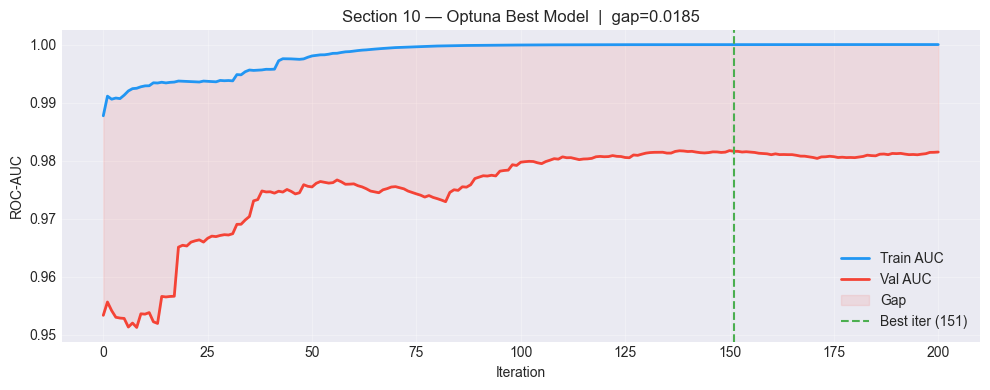

In [30]:
# Build final params from Optuna best trial
# Strip imb_strategy from params and apply it correctly
best_trial_params = {k: v for k, v in study.best_params.items() if k != "imb_strategy"}
best_imb_strategy = study.best_params.get("imb_strategy", "none")

if best_imb_strategy == "scale_pos_weight":
    final_imb = {"scale_pos_weight": SCALE_POS_WEIGHT}
elif best_imb_strategy == "is_unbalance":
    final_imb = {"is_unbalance": True}
else:
    final_imb = {}

best_params = {
    "objective"    : "binary",
    "metric"       : LGBM_METRIC,
    "verbosity"    : -1,
    "random_state" : RANDOM_STATE,
    "n_estimators" : 1000,
    **best_trial_params,
    **final_imb,
}

clf_optuna = LGBMClassifier(**best_params)
clf_optuna.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric=LGBM_METRIC,
    callbacks=[
        early_stopping(50, verbose=False),
        log_evaluation(100),
    ],
)
res_optuna = evaluate(clf_optuna, "Optuna Auto-Tune")
plot_curves(clf_optuna, "Section 10 — Optuna Best Model")


---
## Section 11 — 🏆 Final Comparison & Best Model


In [31]:
comparable = {k: v for k, v in all_experiment_results.items() if k != "Baseline (overfit)"}

print("  {:<32} {:>8} {:>7} {:>10} {:>10}".format("Experiment","ROC-AUC","AUPRC","Gap(roc)","Status"))
print("-" * 72)
for name, r in all_experiment_results.items():
    _v_roc   = r.get("val_roc_auc")
    _v_auprc = r.get("val_auprc")
    roc      = _v_roc   if _v_roc   is not None else (r.get("val") or 0)
    auprc    = _v_auprc if _v_auprc is not None else (r.get("val") or 0)
    g     = r.get("gap", 0)
    roc_s   = f"{roc:.4f}"   if roc   else "  -   "
    auprc_s = f"{auprc:.4f}" if auprc else "  -   "
    is_baseline = name == "Baseline (overfit)"
    prefix  = ">>> " if name == "Optuna Auto-Tune" else ("!!! " if is_baseline else "    ")
    print(f"{prefix}{name:<30} {roc_s:>8} {auprc_s:>7} {g:>8.4f}  {gap_flag(g)}")

print("")
print("=" * 60)
print("AUTO-DIAGNOSIS SUMMARY")
print("=" * 60)

optuna_r   = all_experiment_results.get("Optuna Auto-Tune", {})
optuna_roc   = optuna_r.get("val_roc_auc", 0)
optuna_auprc = optuna_r.get("val_auprc",   0)
optuna_gap   = optuna_r.get("gap", 0)
optuna_prim  = optuna_r.get("val", 0)

print(f"Overfitting metric: {OVERFITTING_METRIC} (gap + early stopping)")
print(f"Evaluation metric : {EVALUATION_METRIC} (reporting + model selection)")
print(f"Optuna ROC-AUC    : {optuna_roc:.4f}")
print(f"Optuna AUPRC      : {optuna_auprc:.4f}")
print(f"Optuna Gap(roc)   : {optuna_gap:.4f}  {gap_flag(optuna_gap)}")
print(f"CV Mean Gap(roc)  : {cv_mean_gap:.4f}  {gap_flag(cv_mean_gap)}")
print(f"Features used     : {len(FEATURES)}")
print(f"Imbalance strategy: {best_imb_strategy}")
print(f"Optuna trials     : {AUTO_TRIALS}")
print("")
print("RECOMMENDATIONS:")
if optuna_gap > GAP_SEVERE:
    print(f"  🔴 Still overfitting ({optuna_gap:.4f}) — try OPTUNA_TRIALS={AUTO_TRIALS*2}")
elif optuna_gap > GAP_MODERATE:
    print(f"  🟡 Moderate gap ({optuna_gap:.4f}) — try OPTUNA_TRIALS={AUTO_TRIALS+25}")
else:
    print(f"  🟢 Healthy gap ({optuna_gap:.4f})")

# AUPRC thresholds depend on baseline (fraud rate) — show relative to random
_baseline_auprc_val = y_val.mean()
_auprc_lift = optuna_auprc / _baseline_auprc_val if _baseline_auprc_val > 0 else 0
if _auprc_lift < 10:
    print(f"  ⚠️  Low AUPRC lift ({_auprc_lift:.1f}x above random={_baseline_auprc_val:.4f}) — check imbalance handling")
elif _auprc_lift < 50:
    print(f"  🟡 Moderate AUPRC lift ({_auprc_lift:.1f}x above random={_baseline_auprc_val:.4f})")
else:
    print(f"  🟢 Strong AUPRC lift ({_auprc_lift:.1f}x above random={_baseline_auprc_val:.4f}) — production ready")


  Experiment                        ROC-AUC   AUPRC   Gap(roc)     Status
------------------------------------------------------------------------
!!! Baseline (overfit)               0.7290  0.1847  -0.0146  🟢
    Regularization                   0.9628  0.7535   0.0372  🟡
    Regularization (num_leaves=15)   0.9676  0.7696   0.0324  🟡
    Subsampling (1.0/0.6)            0.9865  0.8225   0.0135  🟢
    Early Stopping                   0.9914  0.8013   0.0057  🟢
    Cleaned Features (30)            0.9914  0.8013   0.0057  🟢
    Cross Validation (mean)          0.9719  0.7620   0.0157  🟢
>>> Optuna Auto-Tune                 0.9817  0.8275   0.0183  🟢

AUTO-DIAGNOSIS SUMMARY
Overfitting metric: roc_auc (gap + early stopping)
Evaluation metric : auprc (reporting + model selection)
Optuna ROC-AUC    : 0.9817
Optuna AUPRC      : 0.8275
Optuna Gap(roc)   : 0.0183  🟢
CV Mean Gap(roc)  : 0.0157  🟢
Features used     : 30
Imbalance strategy: none
Optuna trials     : 50

RECOMMENDATIONS:
  🟢 Hea

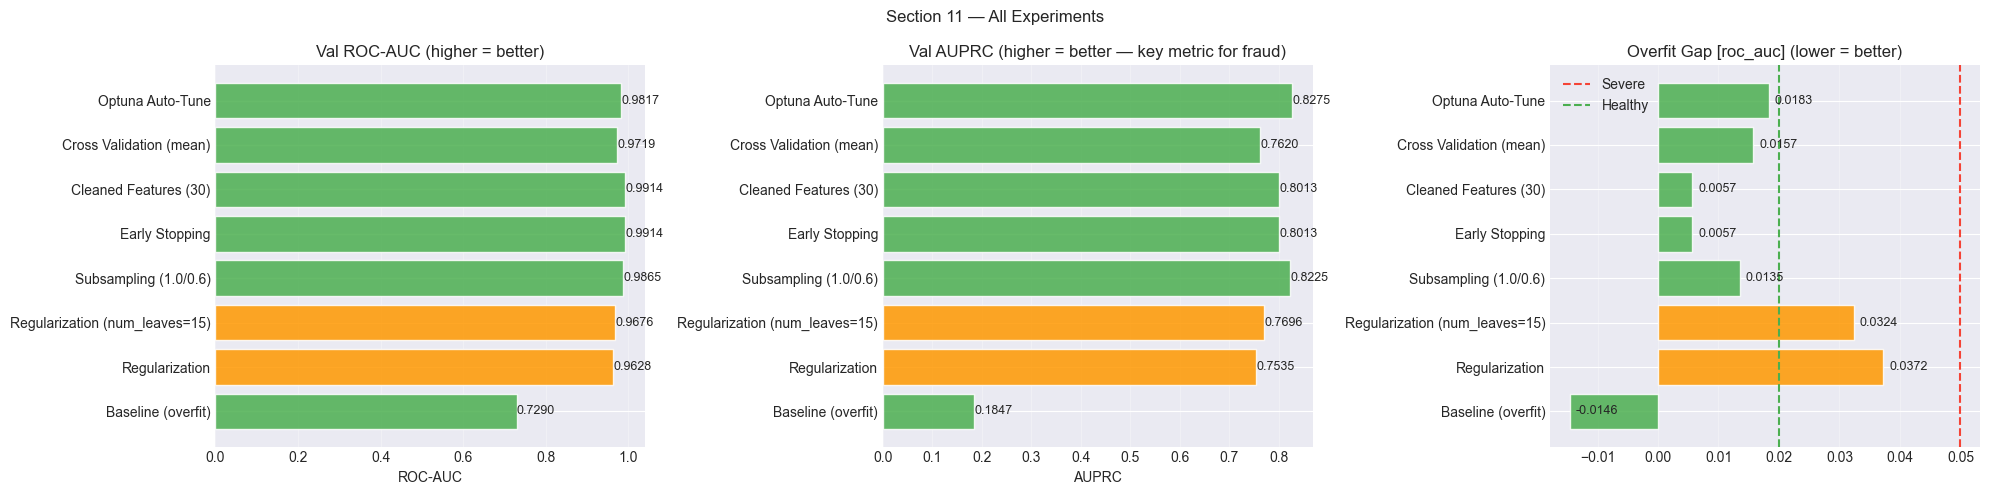

In [32]:
names      = list(all_experiment_results.keys())
roc_vals   = [r.get("val_roc_auc") or r.get("val") or 0 for r in all_experiment_results.values()]
auprc_vals = [r.get("val_auprc")   or r.get("val") or 0 for r in all_experiment_results.values()]
gaps       = [r.get("gap", 0) for r in all_experiment_results.values()]
colors     = [COLORS["val"] if g > GAP_SEVERE else
               (COLORS["warn"] if g > GAP_MODERATE else COLORS["good"]) for g in gaps]

fig, axes = plt.subplots(1, 3, figsize=(20, max(5, len(names)*0.6)))

axes[0].barh(names, roc_vals, color=colors, alpha=0.85, edgecolor="white")
for i, v in enumerate(roc_vals):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
axes[0].set_title("Val ROC-AUC (higher = better)")
axes[0].set_xlabel("ROC-AUC"); axes[0].grid(alpha=0.3, axis="x")

axes[1].barh(names, auprc_vals, color=colors, alpha=0.85, edgecolor="white")
for i, v in enumerate(auprc_vals):
    axes[1].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
axes[1].set_title("Val AUPRC (higher = better — key metric for fraud)")
axes[1].set_xlabel("AUPRC"); axes[1].grid(alpha=0.3, axis="x")

axes[2].barh(names, gaps, color=colors, alpha=0.85, edgecolor="white")
for i, v in enumerate(gaps):
    axes[2].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
axes[2].axvline(GAP_SEVERE,   color=COLORS["val"],  lw=1.5, linestyle="--", label="Severe")
axes[2].axvline(GAP_MODERATE, color=COLORS["good"], lw=1.5, linestyle="--", label="Healthy")
axes[2].set_title("Overfit Gap [roc_auc] (lower = better)")
axes[2].legend(); axes[2].grid(alpha=0.3, axis="x")

plt.suptitle("Section 11 — All Experiments", fontsize=12)
plt.tight_layout(); plt.show()


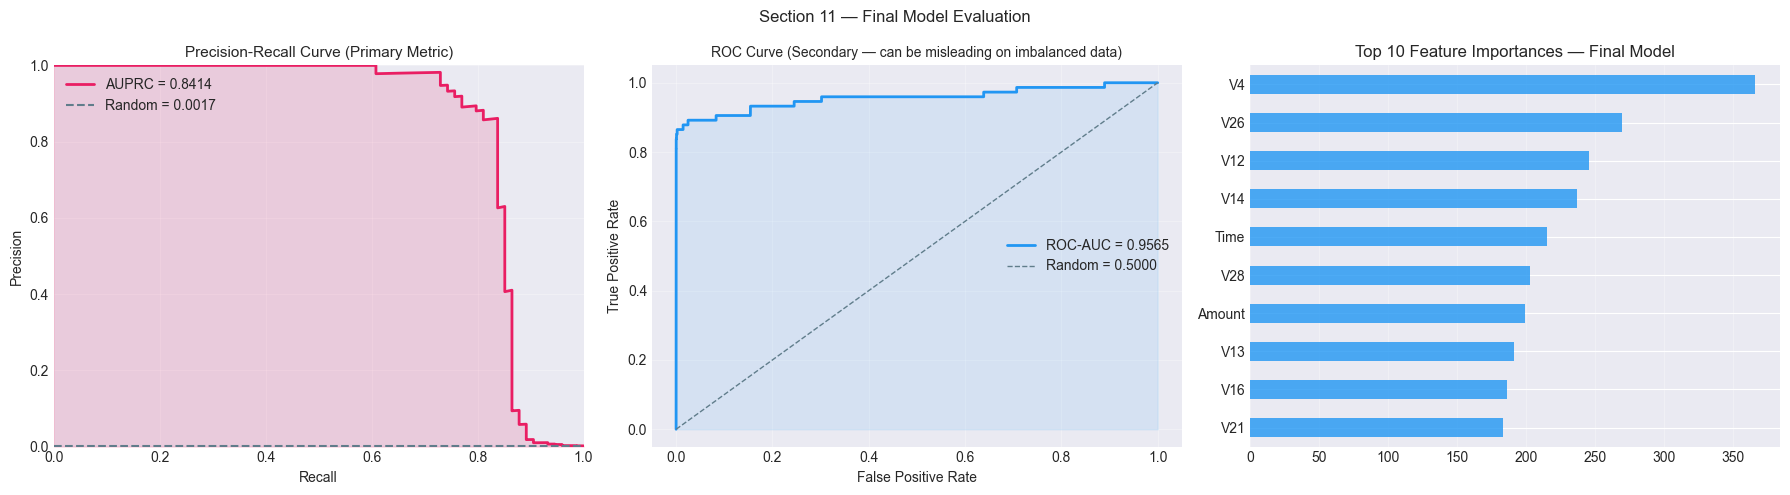

FINAL MODEL — TEST SET RESULTS
AUPRC    : 0.8414  <-- EVALUATION METRIC (fraud detection quality)
Baseline : 0.0017  (random classifier)
Lift     : 485.8x above random
ROC-AUC  : 0.9565  (used for gap detection and early stopping)


In [33]:
best_model = clf_optuna
test_proba = get_proba(best_model, X_test)

test_roc   = roc_auc_score(y_test, test_proba)
test_auprc = average_precision_score(y_test, test_proba)
baseline_auprc = y_test.mean()

fpr, tpr, _            = roc_curve(y_test, test_proba)
prec_vals, rec_vals, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Primary: Precision-Recall curve ─────────────────────────────────────
axes[0].plot(rec_vals, prec_vals, color=COLORS["shap"], lw=2,
             label=f"AUPRC = {test_auprc:.4f}")
axes[0].axhline(baseline_auprc, color=COLORS["neutral"], lw=1.5,
                linestyle="--", label=f"Random = {baseline_auprc:.4f}")
axes[0].fill_between(rec_vals, prec_vals, alpha=0.15, color=COLORS["shap"])
axes[0].set_title("Precision-Recall Curve (Primary Metric)", fontsize=11)
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Secondary: ROC curve ─────────────────────────────────────────────────
axes[1].plot(fpr, tpr, color=COLORS["train"], lw=2,
             label=f"ROC-AUC = {test_roc:.4f}")
axes[1].plot([0,1],[0,1], color=COLORS["neutral"], lw=1,
             linestyle="--", label="Random = 0.5000")
axes[1].fill_between(fpr, tpr, alpha=0.1, color=COLORS["train"])
axes[1].set_title("ROC Curve (Secondary — can be misleading on imbalanced data)", fontsize=10)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── Feature importance ───────────────────────────────────────────────────
_fi_show = min(_chart_top_n, len(FEATURES))
fi_final = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
fi_final.tail(_fi_show).plot(kind="barh", ax=axes[2],
                             color=COLORS["train"], alpha=0.8)
axes[2].set_title(f"Top {_fi_show} Feature Importances — Final Model")
axes[2].grid(alpha=0.3, axis="x")

plt.suptitle("Section 11 — Final Model Evaluation", fontsize=12)
plt.tight_layout(); plt.show()

print("=" * 50)
print("FINAL MODEL — TEST SET RESULTS")
print("=" * 50)
print(f"AUPRC    : {test_auprc:.4f}  <-- EVALUATION METRIC (fraud detection quality)")
print(f"Baseline : {baseline_auprc:.4f}  (random classifier)")
print(f"Lift     : {test_auprc/baseline_auprc:.1f}x above random")
print(f"ROC-AUC  : {test_roc:.4f}  (used for gap detection and early stopping)")
print("=" * 50)


In [34]:
# Classification report at default threshold 0.5
# Note: for imbalanced data, tune the threshold to balance precision/recall
# rather than relying on 0.5 as the cutoff
print("Classification Report (threshold=0.5):")
print("Note: adjust threshold based on business cost of FP vs FN")
print()
print(classification_report(
    y_test,
    (get_proba(best_model, X_test) > 0.5).astype(int),
    target_names=[NEGATIVE_LABEL, POSITIVE_LABEL]
))


Classification Report (threshold=0.5):
Note: adjust threshold based on business cost of FP vs FN

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     42648
       Fraud       0.93      0.74      0.83        74

    accuracy                           1.00     42722
   macro avg       0.97      0.87      0.91     42722
weighted avg       1.00      1.00      1.00     42722



In [35]:

# ── Save model and feature list ─────────────────────────────────────────
joblib.dump(clf_optuna, "lgbm_model.pkl")
clf_optuna.booster_.save_model("lgbm_model.txt")  # LightGBM native format

with open("lgbm_features.json", "w") as f:
    _json.dump({"features": FEATURES, "target": TARGET_COL,
                "positive_label": POSITIVE_LABEL,
                "overfitting_metric": OVERFITTING_METRIC,
                "evaluation_metric": EVALUATION_METRIC}, f, indent=2)

print(f"Model saved: lgbm_model.pkl  lgbm_model.txt")
print(f"Features saved: lgbm_features.json ({len(FEATURES)} features)")

# ── Find optimal threshold on val set ───────────────────────────────────
val_proba  = get_proba(clf_optuna, X_val)
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max F1 on val): {best_thresh:.2f}")
print(f"Use this instead of 0.5 for fraud detection")

# ── Production prediction function ──────────────────────────────────────
def predict_fraud(X_new, threshold=None):
    """
    Production prediction function.
    Returns probability and binary prediction for each row.
    X_new must have the same features as FEATURES.
    """
    if threshold is None:
        threshold = best_thresh
    X_new = X_new[FEATURES]  # ensure correct feature order
    proba = clf_optuna.predict_proba(X_new)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return proba, pred

print()
print("Example usage:")
print("  proba, pred = predict_fraud(X_test)")
print(f"  Threshold used: {best_thresh:.2f}")

# Validate on test set with optimal threshold
test_proba_final, test_pred_final = predict_fraud(X_test)
print()
print(f"Test set with threshold={best_thresh:.2f}:")
print(classification_report(y_test, test_pred_final,
                             target_names=[NEGATIVE_LABEL, POSITIVE_LABEL]))


Model saved: lgbm_model.pkl  lgbm_model.txt
Features saved: lgbm_features.json (30 features)
Optimal threshold (max F1 on val): 0.58
Use this instead of 0.5 for fraud detection

Example usage:
  proba, pred = predict_fraud(X_test)
  Threshold used: 0.58

Test set with threshold=0.58:
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     42648
       Fraud       0.95      0.74      0.83        74

    accuracy                           1.00     42722
   macro avg       0.97      0.87      0.92     42722
weighted avg       1.00      1.00      1.00     42722



In [36]:
print("=" * 55)
print("BEST CONFIG — Copy-paste ready")
print("=" * 55)
print()
print("from lightgbm import LGBMClassifier, early_stopping, log_evaluation")
print()
print("clf = LGBMClassifier(")
print('    objective         = "binary",')
print('    metric            = "auc",  # roc-auc for training stability')
for k, v in best_trial_params.items():
    # Skip subsample_freq when subsample=1.0 (no row sampling)
    if k == "subsample_freq" and best_trial_params.get("subsample", 1.0) >= 1.0:
        continue
    val_str = f"{v:.4f}" if isinstance(v, float) else str(v)
    print(f"    {k:<22} = {val_str},")
if best_imb_strategy == "scale_pos_weight":
    print(f"    scale_pos_weight   = {SCALE_POS_WEIGHT},")
elif best_imb_strategy == "is_unbalance":
    print("    is_unbalance       = True,")
print("    n_estimators       = 1000,")
print("    random_state       = 42,")
print(")")
print()
print("clf.fit(")
print("    X_train, y_train,")
print("    eval_set=[(X_val, y_val)],")
print('    eval_metric="auc",')
print("    callbacks=[")
print("        early_stopping(stopping_rounds=50),")
print("        log_evaluation(100),")
print("    ],")
print(")")
print()
print(f"# Features used ({len(FEATURES)}):")
print(f"# {FEATURES}")


BEST CONFIG — Copy-paste ready

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

clf = LGBMClassifier(
    objective         = "binary",
    metric            = "auc",  # roc-auc for training stability
    num_leaves             = 37,
    max_depth              = 7,
    min_child_samples      = 90,
    reg_alpha              = 0.0110,
    reg_lambda             = 1.8678,
    min_split_gain         = 0.0721,
    subsample              = 0.9706,
    colsample_bytree       = 0.8217,
    learning_rate          = 0.0381,
    n_estimators       = 1000,
    random_state       = 42,
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(100),
    ],
)

# Features used (30):
# ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27'